<a href="https://colab.research.google.com/github/bvsvarshini/ds_varshini/blob/main/notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
trades = pd.read_csv("csv_files/historical_data.csv")
sentiment = pd.read_csv("csv_files/fear_greed_index.csv")

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)
trades['trade_date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    dayfirst=True,
    errors='coerce'
)
sentiment['sentiment_date'] = sentiment['date'].dt.date

In [ ]:
btc_trades = trades[trades['Coin'].str.contains('BTC', case=False)].copy()
btc_trades['is_profitable'] = btc_trades['Closed PnL'] > 0
btc_trades['pnl_ratio'] = btc_trades['Closed PnL'] / btc_trades['Size USD']

In [ ]:
merged = btc_trades.merge(
    sentiment[['sentiment_date', 'classification']],
    left_on='trade_date',
    right_on='sentiment_date',
    how='left'
)

valid_data = merged[merged['classification'].notna()].copy()

print("Sentiment distribution:")
print(valid_data['classification'].value_counts())

Sentiment distribution:
classification
Greed            1483
Fear              988
Extreme Greed     319
Neutral           227
Extreme Fear      145
Name: count, dtype: int64


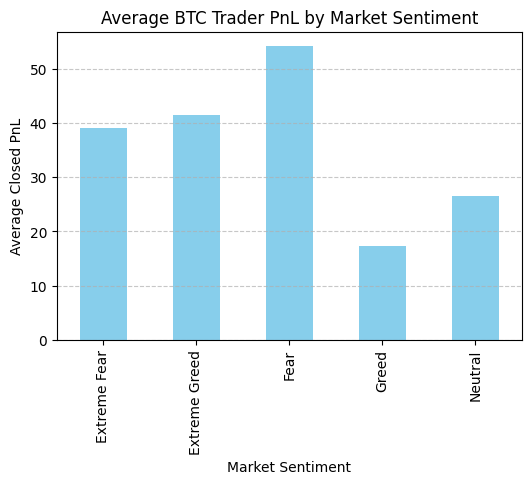

In [ ]:
import os

os.makedirs("outputs", exist_ok=True)

avg_pnl = valid_data.groupby('classification')['Closed PnL'].mean()

plt.figure(figsize=(6,4))
avg_pnl.plot(kind='bar', color='skyblue')  # Pandas plotting works here
plt.title("Average BTC Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Optional for readability

plt.savefig("outputs/avg_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()


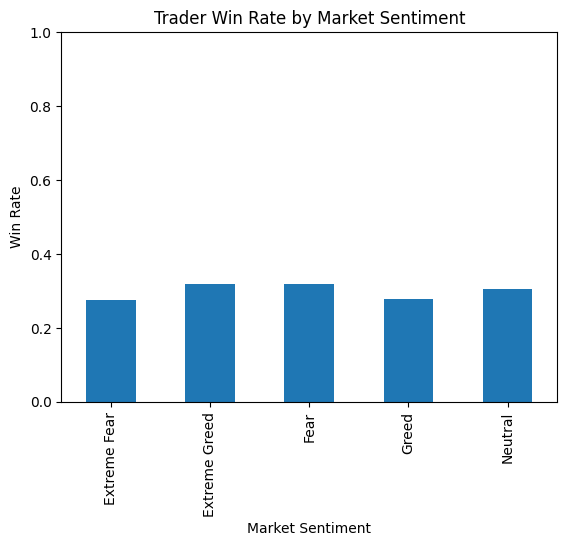

In [ ]:
win_rate = valid_data.groupby('classification')['is_profitable'].mean()

plt.figure()
win_rate.plot(kind='bar')
plt.title("Trader Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.savefig("outputs/win_rate_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

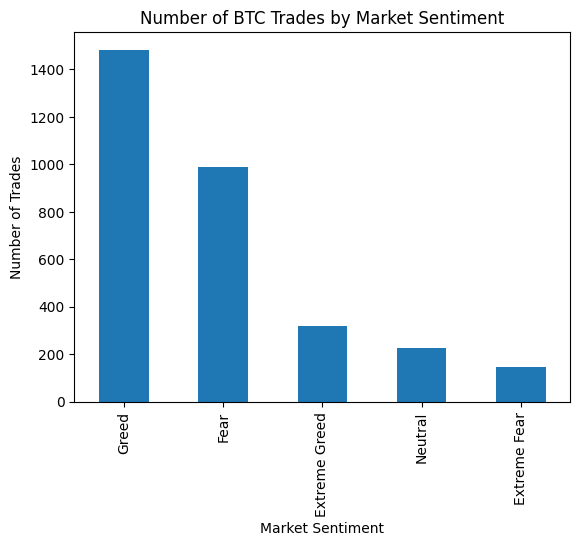

In [ ]:
trade_counts = valid_data['classification'].value_counts()

plt.figure()
trade_counts.plot(kind='bar')
plt.title("Number of BTC Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.savefig("outputs/trade_count_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()


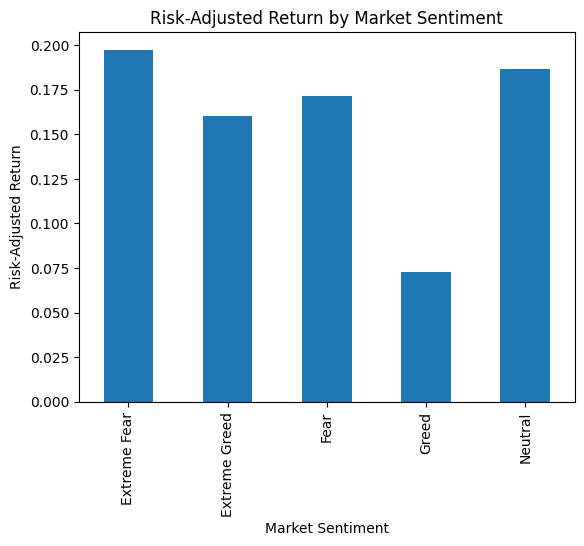

In [ ]:
risk_metrics = (
    valid_data
    .groupby('classification')
    .agg(
        avg_pnl=('Closed PnL', 'mean'),
        pnl_std=('Closed PnL', 'std')
    )
)

risk_metrics['risk_adjusted_return'] = (
    risk_metrics['avg_pnl'] / risk_metrics['pnl_std']
)

plt.figure()
risk_metrics['risk_adjusted_return'].plot(kind='bar')
plt.title("Risk-Adjusted Return by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Risk-Adjusted Return")
plt.savefig("outputs/risk_adjusted_return.png", dpi=300, bbox_inches="tight")
plt.show()